# Exploración de parámetros por conjunto

Búsqueda de la mejor configuración de Fair-GAD y de Fair-MAD **para cada conjunto**, con el compromiso entre equidad y rendimiento como criterio.

La selección por conjunto amplía el espacio de búsqueda y con ello el riesgo de ajustar al ruido de las semillas de exploración. Se contiene de tres formas: promediando sobre tres semillas, exigiendo que la configuración elegida no empeore en ninguna de ellas, y prefiriendo la menor intensidad que satisface el criterio en lugar de la de mejor puntuación.

### Condiciones de factibilidad

1. **Reduce la disparidad**: la variación media de la disparidad agregada es inferior a `UMBRAL_REDUCCION` (−0,005).
2. **No degrada el rendimiento**: la caída media de exactitud no supera `MAX_CAIDA_EXACTITUD` (0,02). A diferencia de la condición previa, este límite es un juicio de valor declarado sobre cuánta exactitud está dispuesto a ceder el trabajo, no una restricción lógica.
3. **No deteriora el impacto dispar**: en tareas binarias, el impacto dispar mínimo no queda por debajo del que presenta el modelo clásico. Impide adoptar configuraciones que reducen la señal agregada destruyendo una métrica concreta.
4. **Es estable**: la disparidad no empeora en ninguna de las semillas por separado.


In [ ]:
import os
import time
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lamda.experiments import runner, reporting
from lamda.experiments import config as cfg
from lamda.fairness.disparity import FairnessThresholds, FairnessWeights
from lamda.models.lamda_classifier import LamdaClassifier
from lamda.models.lamda_fair_gad_classifier import LamdaFairGADClassifier
from lamda.models.lamda_fair_mad_classifier import LamdaFairMADClassifier

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)


## Panel de configuración

La parte común al experimento reproduce la del notebook de mitigación. Lo único que cambia son las semillas y las rejillas de búsqueda.

In [ ]:
# =========================================================
# CONFIGURACIÓN COMÚN (idéntica a la de mitigación)
# =========================================================
ALPHA    = 0.65
OPERATOR = "minmax"
THRESHOLDS = FairnessThresholds(spd=0.1, eod=0.1, di=0.8)

NORMALIZAR_DISPARIDAD = True
CLASS_AGGREGATION     = "mean"
COMPOSICION_DEFECTO   = {"spd": 1.0, "eod": 1.0, "di": 1.0}
COMPOSICION_POR_DATASET = {
    "adult":       {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "dutch":       {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "compas":      {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "oulad":       {"spd": 1.0, "eod": 1.0, "di": 0.0},
    "communities": {"spd": 1.0, "eod": 1.0, "di": 0.0},
    "student":     {"spd": 1.0, "eod": 1.0, "di": 0.0},
}

def pesos_de(dataset):
    """Pesos de composición de la disparidad agregada de un conjunto."""
    comp = COMPOSICION_POR_DATASET.get(dataset, COMPOSICION_DEFECTO)
    return FairnessWeights(spd=comp["spd"], eod=comp["eod"], di=comp["di"],
                           normalize=NORMALIZAR_DISPARIDAD)

EXCLUIR_ATRIBUTO_SENSIBLE = False
TEST_SIZE = 0.2
TAU_J = 0.0
USE_CUMULATIVE_HISTORY = True
DEFAULT_GROUP_DISPARITY = 0.0
UPDATE_EVERY_N_BLOCKS = 1

# =========================================================
# 2. PARTICIONES: LA DE REPORTE NO PARTICIPA EN LA SELECCIÓN
# =========================================================
SEMILLA_REPORTE      = 42          # no se usa en este notebook
SEMILLAS_EXPLORACION = (7, 13, 21) # reducir a (7,) para una pasada rápida

# =========================================================
# 3. CONJUNTOS
# =========================================================
DATASETS = ["adult", "dutch", "compas", "communities", "student"]

# =========================================================
# CONFIGURACIÓN DE REFERENCIA (la actual de mitigación)
# =========================================================
LAMBDA_REFERENCIA   = 0.3
ETA_REFERENCIA      = 10
MODO_MAD_REFERENCIA = "symmetric"

# =========================================================
# 5. REJILLAS DE BÚSQUEDA
# =========================================================
LAMBDAS  = [0.1, 0.2, 0.3, 0.5, 0.8, 1.2]
MAD_GRID = [("symmetric", 5), ("symmetric", 10), ("symmetric", 20),
            ("symmetric", 50),
            ("directional", 10), ("directional", 20),
            ("directional", 50), ("directional", 100), ("directional", 200)]

# =========================================================
# 6. CRITERIO DE SELECCIÓN (fijado antes de ver los resultados)
# =========================================================
EXIGIR_SUPERAR_TRIVIAL = True   # condición previa, medida sobre la F1 macro
UMBRAL_REDUCCION       = -0.005 # variación media de D_g exigida
MAX_CAIDA_EXACTITUD    = 0.02   # caída media de exactitud tolerada
EXIGIR_DI_NO_PEOR      = True   # en binarios, el DI mínimo no puede empeorar
EXIGIR_ESTABILIDAD     = True   # ninguna semilla puede empeorar la disparidad
FRACCION_PUNTUACION    = 0.90   # parsimonia acotada: 90 % de la mejor puntuación

# Si los barridos ya están guardados en disco, se reutilizan en lugar de
# repetirlos. Permite recalcular la selección en segundos tras cambiar el
# criterio, sin volver a entrenar nada.
REUTILIZAR_BARRIDOS = False 

RESULTADOS_DIR = os.path.join(cfg.RESULTS_DIR, "exploracion")
os.makedirs(RESULTADOS_DIR, exist_ok=True)


In [ ]:
# Esquema por bloques, derivado del tamaño de cada conjunto. Idéntico al del
# notebook de mitigación: no forma parte de la búsqueda.
BLOQUES_OBJETIVO     = 20
TAMANO_BLOQUE_MINIMO = 32
MODO_SOPORTES        = "auto"

CONFIG_BLOQUES = {}
for _n in DATASETS:
    _Xtr, _Xte, _ytr, *_ = runner.load_and_split(
        _n, test_size=TEST_SIZE, random_state=SEMILLA_REPORTE,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)
    _bs = cfg.tamano_bloque(len(_Xtr), BLOQUES_OBJETIVO, TAMANO_BLOQUE_MINIMO)
    _mg, _mp = cfg.soportes_minimos(len(_Xtr), n_classes=int(len(np.unique(_ytr))),
                                    block_size=_bs, modo=MODO_SOPORTES)
    # Fair-GAD no recibe la frecuencia de actualización: recalcula el estado
    # de equidad en cada bloque por construcción. Solo Fair-MAD la admite.
    CONFIG_BLOQUES[_n] = dict(block_size=_bs, min_group_size=_mg,
                              min_positive_size=_mp)

pd.DataFrame(CONFIG_BLOQUES).T


,block_size,min_group_size,min_positive_size
adult,1206,50,25
dutch,2417,50,25
compas,212,50,25
communities,80,40,13
student,32,20,8


## Motor del barrido

Las particiones y el modelo clásico se calculan una sola vez por conjunto y semilla y quedan en caché, de modo que cada configuración solo paga el entrenamiento del modelo que se está evaluando.

In [ ]:
_CACHE = {}

def datos_de(dataset, semilla):
    """Partición y métricas del modelo clásico, con caché."""
    clave = (dataset, semilla)
    if clave in _CACHE:
        return _CACHE[clave]
    Xtr, Xte, ytr, yte, str_, ste, fnames, dcfg = runner.load_and_split(
        dataset, test_size=TEST_SIZE, random_state=semilla,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)
    tarea = "binary" if int(len(np.unique(ytr))) == 2 else "multiclass"
    base = LamdaClassifier(alpha=ALPHA, operator=OPERATOR).fit(Xtr, ytr)
    m_base = reporting.summarize_model_metrics(
        yte, base.predict(Xte), ste, task=tarea,
        thresholds=THRESHOLDS, weights=pesos_de(dataset),
        class_aggregation=CLASS_AGGREGATION)
    # Predictor de clase mayoritaria sobre el mismo test. La condición previa
    # se evalúa sobre la F1 macro, que bajo desbalance distingue mejor que la
    # exactitud entre un clasificador que discrimina y uno que no.
    from sklearn.metrics import f1_score
    valores, cuentas = np.unique(yte, return_counts=True)
    mayoritaria = valores[int(np.argmax(cuentas))]
    y_trivial = np.full_like(yte, mayoritaria)
    acc_trivial = float(cuentas.max() / len(yte))
    f1_trivial = float(f1_score(yte, y_trivial, average="macro", zero_division=0))
    _CACHE[clave] = dict(Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, str_=str_, ste=ste,
                         tarea=tarea, base=m_base, acc_trivial=acc_trivial,
                         f1_trivial=f1_trivial)
    return _CACHE[clave]


def _fila(dataset, semilla, propuesta, etiqueta, y_pred, extra):
    """Métricas de una configuración, comparadas con el modelo clásico."""
    d = datos_de(dataset, semilla)
    m = reporting.summarize_model_metrics(
        d["yte"], y_pred, d["ste"], task=d["tarea"],
        thresholds=THRESHOLDS, weights=pesos_de(dataset),
        class_aggregation=CLASS_AGGREGATION)
    b = d["base"]
    di, di_b = m.get("min_di", np.nan), b.get("min_di", np.nan)
    return {"Dataset": cfg.DATASETS[dataset].display_name, "dataset": dataset,
            "Tarea": d["tarea"], "Semilla": semilla, "Propuesta": propuesta,
            "Config": etiqueta,
            "Accuracy": m["Accuracy"], "F1_macro": m["F1_macro"],
            "Acc_trivial": d["acc_trivial"], "F1_trivial": d["f1_trivial"],
            "Supera trivial": bool(m["F1_macro"] > d["f1_trivial"]),
            "D_g": m["mean_disparity"], "|SPD|": m["mean_abs_spd"],
            "|EOD|": m["mean_abs_eod"], "DI_min": di,
            "Delta Acc": m["Accuracy"] - b["Accuracy"],
            "Delta D_g": m["mean_disparity"] - b["mean_disparity"],
            "Delta DI_min": di - di_b if np.isfinite(di) and np.isfinite(di_b) else np.nan,
            **extra}


def evaluar_gad(dataset, semilla, lambda_, modo="directional"):
    """Entrena Fair-GAD con una intensidad y devuelve su fila de resultados."""
    d = datos_de(dataset, semilla)
    mdl = LamdaFairGADClassifier(
        alpha=ALPHA, operator=OPERATOR, lambda_=lambda_,
        fairness_thresholds=THRESHOLDS, fairness_weights=pesos_de(dataset),
        clip=True, default_group_disparity=DEFAULT_GROUP_DISPARITY,
        class_aggregation=CLASS_AGGREGATION,
        use_cumulative_history=USE_CUMULATIVE_HISTORY,
        disparity_mode=modo, **CONFIG_BLOQUES[dataset])
    mdl.fit(d["Xtr"], d["ytr"])
    mdl.predict_blocks(X=d["Xtr"], y_true=d["ytr"], sensitive=d["str_"],
                       return_details=False)
    y_pred = mdl.predict_fair_from_disparities(X=d["Xte"], sensitive=d["ste"])
    return _fila(dataset, semilla, "Fair-GAD", f"lambda={lambda_}", y_pred,
                 {"lambda": lambda_, "modo": modo, "eta": np.nan,
                  "w_min": np.nan, "atenuados": np.nan})


def evaluar_mad(dataset, semilla, modo, eta):
    """Entrena Fair-MAD con una señal e intensidad y devuelve su fila."""
    d = datos_de(dataset, semilla)
    mdl = LamdaFairMADClassifier(
        alpha=ALPHA, operator=OPERATOR, eta=eta, tau_j=TAU_J,
        fairness_thresholds=THRESHOLDS, fairness_weights=pesos_de(dataset),
        clip=True, default_group_disparity=DEFAULT_GROUP_DISPARITY,
        class_aggregation=CLASS_AGGREGATION,
        use_cumulative_history=USE_CUMULATIVE_HISTORY,
        disparity_mode=modo, update_every_n_blocks=UPDATE_EVERY_N_BLOCKS,
        **CONFIG_BLOQUES[dataset])
    mdl.fit(d["Xtr"], d["ytr"])
    mdl.predict_blocks(X=d["Xtr"], y_true=d["ytr"], sensitive=d["str_"],
                       return_details=False)
    y_pred = mdl.predict_fair_from_weights(X=d["Xte"])
    w = np.asarray(mdl.descriptor_weights_, dtype=float)
    return _fila(dataset, semilla, "Fair-MAD", f"{modo}, eta={eta}", y_pred,
                 {"lambda": np.nan, "modo": modo, "eta": eta,
                  "w_min": float(w.min()), "atenuados": int((w < 0.99).sum())})


## Barrido de Fair-GAD

Intensidad de la penalización sobre el grado de adecuación global, con señal direccional.

In [ ]:
ruta_gad = os.path.join(RESULTADOS_DIR, "barrido_gad.csv")
if REUTILIZAR_BARRIDOS and os.path.exists(ruta_gad):
    barrido_gad = pd.read_csv(ruta_gad)
    print(f"Barrido de Fair-GAD reutilizado desde {ruta_gad} "
          f"({len(barrido_gad)} filas). Poner REUTILIZAR_BARRIDOS = False para repetirlo.")
else:
    filas_gad = []
    t0 = time.time()
    for semilla in SEMILLAS_EXPLORACION:
        for name in DATASETS:
            ti = time.time()
            for lam in LAMBDAS:
                filas_gad.append(evaluar_gad(name, semilla, lam))
            print(f"[semilla {semilla}][{name}] {time.time()-ti:.0f}s", flush=True)
    barrido_gad = pd.DataFrame(filas_gad)
    barrido_gad.to_csv(ruta_gad, index=False)

resumen_gad = (barrido_gad.groupby(["Dataset", "lambda"])
               [["Delta D_g", "Delta Acc", "Delta DI_min", "D_g", "Accuracy"]]
               .mean().round(4))
resumen_gad


[semilla 7][adult] 3s
[semilla 7][dutch] 7s
[semilla 7][compas] 1s
[semilla 7][communities] 0s
[semilla 7][student] 0s
[semilla 13][adult] 3s
[semilla 13][dutch] 7s
[semilla 13][compas] 1s
[semilla 13][communities] 0s
[semilla 13][student] 0s
[semilla 21][adult] 3s
[semilla 21][dutch] 7s
[semilla 21][compas] 1s
[semilla 21][communities] 0s
[semilla 21][student] 0s


Delta D_g  Delta Acc  Delta DI_min    D_g  Accuracy
Dataset               lambda                                                     
Adult                 0.1000    -0.0489    -0.0067        0.1399 0.0279    0.7515
                      0.2000    -0.0557    -0.0082        0.1699 0.0211    0.7500
                      0.3000    -0.0569    -0.0081        0.1772 0.0199    0.7501
                      0.5000    -0.0576    -0.0087        0.1822 0.0192    0.7495
                      0.8000    -0.0578    -0.0097        0.1962 0.0190    0.7486
                      1.2000    -0.0621    -0.0101        0.2105 0.0147    0.7481
COMPAS                0.1000    -0.0505    -0.0025        0.0511 0.2425    0.6102
                      0.2000    -0.1701    -0.0101        0.1913 0.1228    0.6026
                      0.3000    -0.1968    -0.0110        0.1820 0.0961    0.6016
                      0.5000    -0.2045    -0.0145        0.1945 0.0885    0.5982
                      0.8000    -0.2262    -0.0208        0.2525 0.0667    0.5919
                      1.2000    -0.2405    -0.0265        0.2813 0.0525    0.5862
Communities and Crime 0.1000    -0.0471    -0.0301        0.0932 0.0592    0.5205
                      0.2000    -0.0602    -0.0459        0.1674 0.0461    0.5046
                      0.3000    -0.0646    -0.0476        0.1745 0.0417    0.5029
                      0.5000    -0.0680    -0.0476        0.1754 0.0383    0.5029
                      0.8000    -0.0690    -0.0468        0.1797 0.0373    0.5038
                      1.2000    -0.0696    -0.0535        0.1979 0.0367    0.4971
Dutch Census          0.1000    -0.0265    -0.0037        0.0529 0.0127    0.7206
                      0.2000    -0.0325    -0.0053        0.0679 0.0068    0.7190
                      0.3000    -0.0330    -0.0055        0.0694 0.0063    0.7188
                      0.5000    -0.0307    -0.0051        0.0655 0.0086    0.7192
                      0.8000    -0.0304    -0.0049        0.0650 0.0088    0.7195
                      1.2000    -0.0254    -0.0081        0.0840 0.0139    0.7162
Student Performance   0.1000     0.0000     0.0026        0.0168 0.0290    0.5231
                      0.2000    -0.0051     0.0000        0.0288 0.0239    0.5205
                      0.3000    -0.0051     0.0000        0.0288 0.0239    0.5205
                      0.5000    -0.0051    -0.0026        0.0479 0.0239    0.5179
                      0.8000    -0.0051     0.0000        0.0288 0.0239    0.5205
                      1.2000     0.0000     0.0000        0.0000 0.0290    0.5205

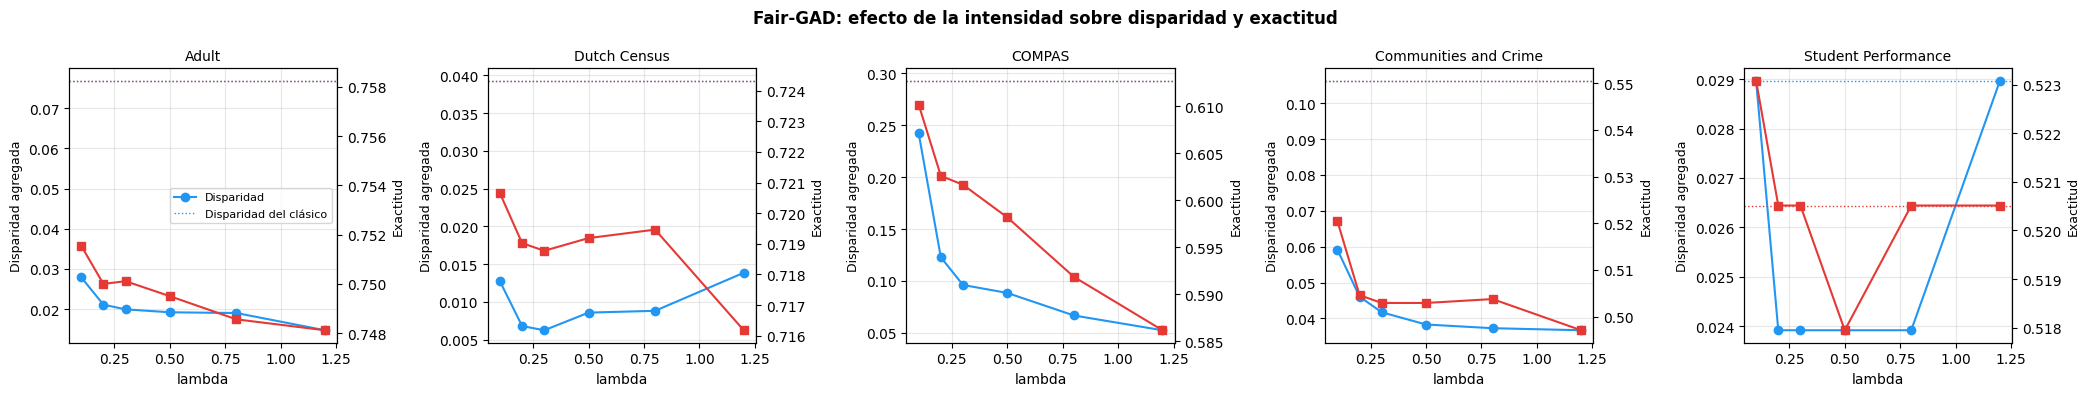

In [ ]:
# Disparidad y exactitud frente a la intensidad, por conjunto.
nombres = [cfg.DATASETS[d].display_name for d in DATASETS]
fig, axes = plt.subplots(1, len(nombres), figsize=(4.2*len(nombres), 4), squeeze=False)
for ax, nombre in zip(axes[0], nombres):
    sub = barrido_gad[barrido_gad["Dataset"] == nombre].groupby("lambda").mean(numeric_only=True)
    ax.plot(sub.index, sub["D_g"], marker="o", color="#2196F3", label="Disparidad")
    ax.axhline(sub["D_g"].iloc[0] - sub["Delta D_g"].iloc[0], color="#2196F3",
               linestyle=":", linewidth=1, label="Disparidad del clásico")
    ax2 = ax.twinx()
    ax2.plot(sub.index, sub["Accuracy"], marker="s", color="#E53935")
    ax2.axhline(sub["Accuracy"].iloc[0] - sub["Delta Acc"].iloc[0], color="#E53935",
                linestyle=":", linewidth=1)
    ax.set_title(nombre, fontsize=10); ax.set_xlabel("lambda")
    ax.set_ylabel("Disparidad agregada", fontsize=9)
    ax2.set_ylabel("Exactitud", fontsize=9); ax.grid(alpha=0.3)
axes[0][0].legend(fontsize=8)
plt.suptitle("Fair-GAD: efecto de la intensidad sobre disparidad y exactitud",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Barrido de Fair-MAD

Señal de control e intensidad de la atenuación por descriptor. La señal forma parte de la búsqueda porque la evidencia disponible es favorable en unos conjuntos y desfavorable en otros.

In [ ]:
ruta_mad = os.path.join(RESULTADOS_DIR, "barrido_mad.csv")
if REUTILIZAR_BARRIDOS and os.path.exists(ruta_mad):
    barrido_mad = pd.read_csv(ruta_mad)
    print(f"Barrido de Fair-MAD reutilizado desde {ruta_mad} "
          f"({len(barrido_mad)} filas). Poner REUTILIZAR_BARRIDOS = False para repetirlo.")
else:
    filas_mad = []
    t0 = time.time()
    for semilla in SEMILLAS_EXPLORACION:
        for name in DATASETS:
            ti = time.time()
            for modo, eta in MAD_GRID:
                filas_mad.append(evaluar_mad(name, semilla, modo, eta))
            print(f"[semilla {semilla}][{name}] {time.time()-ti:.0f}s", flush=True)
    barrido_mad = pd.DataFrame(filas_mad)
    barrido_mad.to_csv(ruta_mad, index=False)

resumen_mad = (barrido_mad.groupby(["Dataset", "modo", "eta"])
               [["Delta D_g", "Delta Acc", "Delta DI_min", "w_min", "atenuados"]]
               .mean().round(4))
resumen_mad


[semilla 7][adult] 178s
[semilla 7][dutch] 205s
[semilla 7][compas] 4s
[semilla 7][communities] 31s
[semilla 7][student] 4s
[semilla 13][adult] 183s
[semilla 13][dutch] 206s
[semilla 13][compas] 4s
[semilla 13][communities] 27s
[semilla 13][student] 4s
[semilla 21][adult] 176s
[semilla 21][dutch] 202s
[semilla 21][compas] 4s
[semilla 21][communities] 28s
[semilla 21][student] 4s


Delta D_g  Delta Acc  Delta DI_min  w_min  atenuados
Dataset               modo        eta                                                      
Adult                 directional 10     -0.0132    -0.0065        0.0355 0.9289     8.6667
                                  20     -0.0196    -0.0095        0.0563 0.8674    12.6667
                                  50     -0.0613    -0.0270        0.2000 0.7236    21.0000
                                  100    -0.0641    -0.0283        0.2149 0.5671    26.0000
                                  200    -0.0702    -0.0434        0.3041 0.3960    35.0000
                      symmetric   5      -0.0160    -0.0066        0.0435 0.8760     9.6667
                                  10     -0.0428    -0.0294        0.1406 0.7794    15.0000
                                  20     -0.0624    -0.0279        0.2040 0.6386    19.3333
                                  50     -0.0715    -0.0389        0.2553 0.4141    27.6667
COMPAS                directional 10     -0.0022    -0.0016       -0.0018 0.7443     2.3333
                                  20      0.0713    -0.0117       -0.2164 0.5928     4.0000
                                  50     -0.0585    -0.0360       -0.1940 0.3681     4.0000
                                  100    -0.0649    -0.0376       -0.1942 0.2257     4.3333
                                  200    -0.0667    -0.0369       -0.2014 0.1272     4.3333
                      symmetric   5      -0.0031    -0.0013       -0.0003 0.8586     2.0000
                                  10     -0.0034    -0.0038       -0.0042 0.7524     2.6667
                                  20      0.0719    -0.0126       -0.2199 0.6032     3.3333
                                  50     -0.0627    -0.0363       -0.1925 0.3784     3.3333
Communities and Crime directional 10      0.0111     0.0033       -0.0279 0.9161    16.3333
                                  20      0.0110     0.0025       -0.0245 0.8453    23.0000
                                  50      0.0085    -0.0050       -0.0703 0.6867    35.0000
                                  100     0.0029    -0.0209       -0.0758 0.5237    35.3333
                                  200     0.0098    -0.0192       -0.0945 0.3555    36.0000
                      symmetric   5       0.0029     0.0025       -0.0061 0.9453     8.3333
                                  10     -0.0006     0.0008       -0.0119 0.8964    15.0000
                                  20      0.0003     0.0050       -0.0070 0.8125    22.0000
                                  50     -0.0060    -0.0042       -0.0329 0.6349    28.3333
Dutch Census          directional 10     -0.0029     0.0011        0.0047 0.9616     9.6667
                                  20     -0.0043    -0.0025        0.0072 0.9260    11.3333
                                  50     -0.0191    -0.0159        0.0295 0.8336    13.3333
                                  100    -0.0245    -0.0188        0.0443 0.7146    14.3333
                                  200    -0.0391    -0.0333        0.1024 0.5560    14.6667
                      symmetric   5      -0.0033     0.0009        0.0057 0.9356    11.0000
                                  10     -0.0154    -0.0098        0.0236 0.8789    12.0000
                                  20     -0.0214    -0.0169        0.0350 0.7840    13.3333
                                  50     -0.0342    -0.0327        0.0694 0.5922    14.6667
Student Performance   directional 10      0.0032     0.0026       -0.0323 0.9646     5.3333
                                  20     -0.0001    -0.0051       -0.0418 0.9326     5.3333
                                  50     -0.0023    -0.0077       -0.0742 0.8523     8.6667
                                  100     0.0012    -0.0026       -0.0674 0.7543     9.3333
                                  200    -0.0069    -0.0051       -0.0333 0.6304     9.3333
                      symmetric   5       0.0033     0.0051       -0.0149 0.9819   

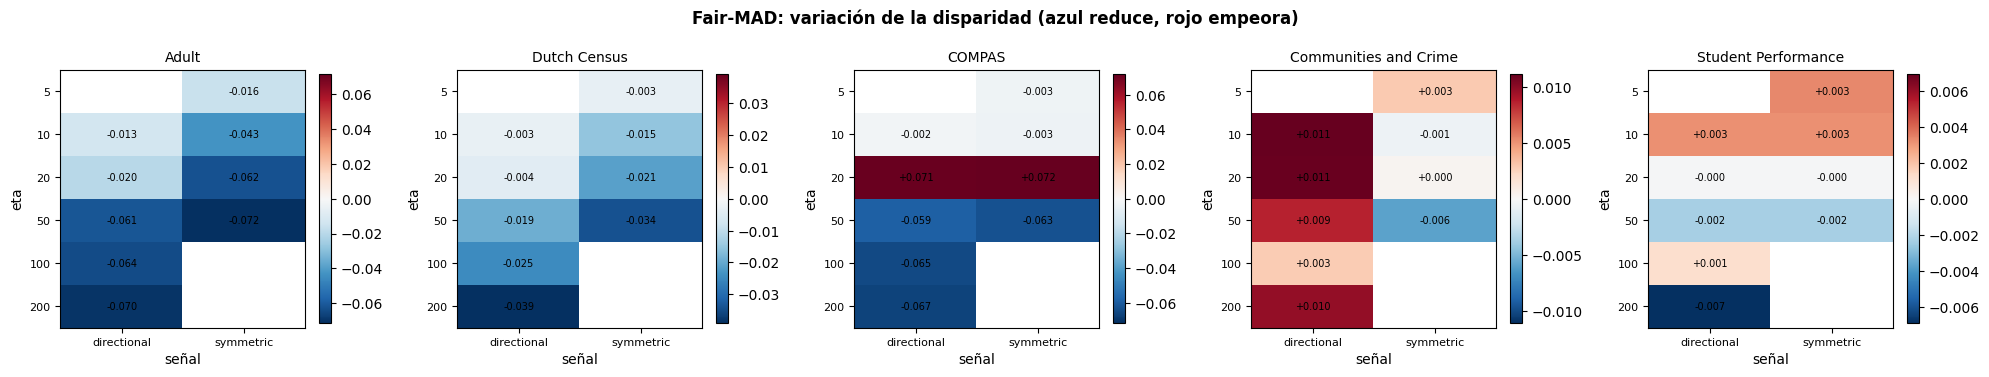

In [ ]:
# Mapa de la variación de disparidad por señal e intensidad.
fig, axes = plt.subplots(1, len(nombres), figsize=(4.0*len(nombres), 3.8), squeeze=False)
for ax, nombre in zip(axes[0], nombres):
    piv = (barrido_mad[barrido_mad["Dataset"] == nombre]
           .pivot_table(index="eta", columns="modo", values="Delta D_g", aggfunc="mean"))
    lim = float(np.nanmax(np.abs(piv.to_numpy()))) or 1e-6
    im = ax.imshow(piv.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, fontsize=8)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index, fontsize=8)
    ax.set_xlabel("señal"); ax.set_ylabel("eta"); ax.set_title(nombre, fontsize=10)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.to_numpy()[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Fair-MAD: variación de la disparidad (azul reduce, rojo empeora)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Aplicación del criterio de selección

El criterio se fijó en el panel de configuración antes de ejecutar los barridos. Se aplica de forma idéntica a los dos mecanismos y a los cinco conjuntos.

In [ ]:
def diagnosticar(barrido, claves):
    """Evalúa la condición previa y las cuatro de factibilidad."""
    filas = []
    for (dataset, *valores), g in barrido.groupby(["dataset"] + claves):
        tarea = g["Tarea"].iloc[0]
        d_dg, d_acc = g["Delta D_g"].mean(), g["Delta Acc"].mean()
        d_di = g["Delta DI_min"].mean()
        # Condición previa: el modelo mitigado debe seguir superando al predictor de
        # clase mayoritaria en todas las semillas.
        cond_trivial = (not EXIGIR_SUPERAR_TRIVIAL
                        or bool(g["Supera trivial"].all()))
        cond_reduce  = d_dg < UMBRAL_REDUCCION
        cond_rendim  = d_acc >= -MAX_CAIDA_EXACTITUD
        cond_di      = (not EXIGIR_DI_NO_PEOR or tarea != "binary"
                        or not np.isfinite(d_di) or d_di >= -1e-9)
        cond_estable = (not EXIGIR_ESTABILIDAD
                        or bool((g["Delta D_g"] < 1e-9).all()))
        valida = (cond_trivial and cond_reduce and cond_rendim
                  and cond_di and cond_estable)
        filas.append({"Dataset": cfg.DATASETS[dataset].display_name,
                      "dataset": dataset,
                      **dict(zip(claves, valores)),
                      "Delta D_g": d_dg, "Delta Acc": d_acc, "Delta DI_min": d_di,
                      "F1 macro": g["F1_macro"].mean(),
                      "F1 macro trivial": g["F1_trivial"].mean(),
                      "0 supera trivial": cond_trivial,
                      "1 reduce": cond_reduce, "2 rendimiento": cond_rendim,
                      "3 impacto dispar": cond_di, "4 estable": cond_estable,
                      "Puntuación": -d_dg - max(0.0, -d_acc),
                      "VÁLIDA": valida})
    return pd.DataFrame(filas)


def seleccionar(diagnostico, clave_intensidad, etiqueta_propuesta=""):
    """
    Elige, por conjunto, la menor intensidad cuya puntuación de compromiso
    alcance la fracción declarada de la mejor puntuación factible.

    Si ninguna configuración es factible, devuelve la de menor intensidad de la
    rejilla y lo declara de forma expresa.
    """
    elegidas = []
    for dataset, g in diagnostico.groupby("dataset"):
        validas = g[g["VÁLIDA"]]
        if len(validas):
            umbral = FRACCION_PUNTUACION * validas["Puntuación"].max()
            fila = (validas[validas["Puntuación"] >= umbral]
                    .sort_values(clave_intensidad).iloc[0])
            origen = "criterio"
        else:
            fila = g.sort_values(clave_intensidad).iloc[0]
            origen = "respaldo: ninguna configuración factible"
        elegidas.append({"Dataset": fila["Dataset"], "dataset": dataset,
                         "Propuesta": etiqueta_propuesta,
                         "elegida": fila[clave_intensidad],
                         "modo": fila.get("modo", "—"),
                         "Delta D_g": fila["Delta D_g"],
                         "Delta Acc": fila["Delta Acc"],
                         "Delta DI_min": fila["Delta DI_min"],
                         "Puntuación": fila["Puntuación"],
                         "Origen": origen,
                         "Nº factibles": int(g["VÁLIDA"].sum())})
    return pd.DataFrame(elegidas).set_index("Dataset")


diag_gad = diagnosticar(barrido_gad, ["lambda"])
diag_mad = diagnosticar(barrido_mad, ["modo", "eta"])
diag_gad.to_csv(os.path.join(RESULTADOS_DIR, "diagnostico_gad.csv"), index=False)
diag_mad.to_csv(os.path.join(RESULTADOS_DIR, "diagnostico_mad.csv"), index=False)

print("DIAGNÓSTICO DE FAIR-GAD")
display(diag_gad.drop(columns=["dataset"]).round(4))
print("\nDIAGNÓSTICO DE FAIR-MAD")
display(diag_mad.drop(columns=["dataset"]).round(4))


DIAGNÓSTICO DE FAIR-GAD


,Dataset,lambda,Delta D_g,Delta Acc,Delta DI_min,F1 macro,F1 macro trivial,0 supera trivial,1 reduce,2 rendimiento,3 impacto dispar,4 estable,Puntuación,VÁLIDA
0,Adult,0.1000,-0.0489,-0.0067,0.1399,0.6939,0.4289,True,True,True,True,True,0.0422,True
1,Adult,0.2000,-0.0557,-0.0082,0.1699,0.6914,0.4289,True,True,True,True,True,0.0475,True
2,Adult,0.3000,-0.0569,-0.0081,0.1772,0.6912,0.4289,True,True,True,True,True,0.0488,True
3,Adult,0.5000,-0.0576,-0.0087,0.1822,0.6907,0.4289,True,True,True,True,True,0.0489,True
4,Adult,0.8000,-0.0578,-0.0097,0.1962,0.6897,0.4289,True,True,True,True,True,0.0481,True
5,Adult,1.2000,-0.0621,-0.0101,0.2105,0.6888,0.4289,True,True,True,True,True,0.0520,True
6,Communities and Crime,0.1000,-0.0471,-0.0301,0.0932,0.5196,0.1695,True,True,False,True,True,0.0170,False
7,Communities and Crime,0.2000,-0.0602,-0.0459,0.1674,0.5064,0.1695,True,True,False,True,True,0.0143,False
8,Communities and Crime,0.3000,-0.0646,-0.0476,0.1745,0.5054,0.1695,True,True,False,True,True,0.0169,False
9,Communities and Crime,0.5000,-0.0680,-0.0476,0.1754,0.5062,0.1695,True,True,False,True,True,0.0204,False



DIAGNÓSTICO DE FAIR-MAD


,Dataset,modo,eta,Delta D_g,Delta Acc,Delta DI_min,F1 macro,F1 macro trivial,0 supera trivial,1 reduce,2 rendimiento,3 impacto dispar,4 estable,Puntuación,VÁLIDA
0,Adult,directional,10,-0.0132,-0.0065,0.0355,0.6980,0.4289,True,True,True,True,True,0.0067,True
1,Adult,directional,20,-0.0196,-0.0095,0.0563,0.6959,0.4289,True,True,True,True,True,0.0101,True
2,Adult,directional,50,-0.0613,-0.0270,0.2000,0.6834,0.4289,True,True,False,True,True,0.0343,False
3,Adult,directional,100,-0.0641,-0.0283,0.2149,0.6823,0.4289,True,True,False,True,True,0.0358,False
4,Adult,directional,200,-0.0702,-0.0434,0.3041,0.6695,0.4289,True,True,False,True,True,0.0268,False
5,Adult,symmetric,5,-0.0160,-0.0066,0.0435,0.6982,0.4289,True,True,True,True,True,0.0093,True
6,Adult,symmetric,10,-0.0428,-0.0294,0.1406,0.6824,0.4289,True,True,False,True,True,0.0135,False
7,Adult,symmetric,20,-0.0624,-0.0279,0.2040,0.6826,0.4289,True,True,False,True,True,0.0345,False
8,Adult,symmetric,50,-0.0715,-0.0389,0.2553,0.6735,0.4289,True,True,False,True,True,0.0327,False
9,Communities and Crime,directional,10,0.0111,0.0033,-0.0279,0.5489,0.1695,True,False,True,True,False,-0.0111,False


In [ ]:
sel_gad = seleccionar(diag_gad, "lambda", "Fair-GAD")
sel_mad = seleccionar(diag_mad, "eta", "Fair-MAD")

print("CONFIGURACIÓN ELEGIDA PARA FAIR-GAD")
display(sel_gad.drop(columns=["dataset", "modo", "Propuesta"]).round(4))
print("\nCONFIGURACIÓN ELEGIDA PARA FAIR-MAD")
display(sel_mad.drop(columns=["dataset", "Propuesta"]).round(4))

# Diccionarios listos para pegar en el panel de mitigación. El respaldo se
# traslada tal cual:
lam_dict  = {r["dataset"]: float(r["elegida"]) for _, r in sel_gad.iterrows()}
eta_dict  = {r["dataset"]: int(r["elegida"]) for _, r in sel_mad.iterrows()}
modo_dict = {r["dataset"]: (r["modo"] if r["modo"] != "—" else MODO_MAD_REFERENCIA)
             for _, r in sel_mad.iterrows()}

# OULAD no participa en la búsqueda: su disparidad de partida es nula y ninguna
# configuración puede alterarla. Toma los valores modales del resto.
def _moda(d, defecto):
    return max(set(d.values()), key=list(d.values()).count) if d else defecto
lam_dict["oulad"]  = _moda(lam_dict, LAMBDA_REFERENCIA)
eta_dict["oulad"]  = _moda(eta_dict, ETA_REFERENCIA)
modo_dict["oulad"] = MODO_MAD_REFERENCIA

def _fmt(d, comilla=False):
    cuerpo = ",\n".join(f'    "{k}": ' + (f'"{v}"' if comilla else f"{v}")
                         for k, v in d.items())
    return "{\n" + cuerpo + ",\n}"

print("\n" + "=" * 70)
print("CONFIG. ELEGIDA")
print("=" * 70)
print("LAMBDA_POR_DATASET =", _fmt(lam_dict))
print("ETA_POR_DATASET =", _fmt(eta_dict))
print("MODO_MAD_POR_DATASET =", _fmt(modo_dict, comilla=True))

incumplen = pd.concat([sel_gad, sel_mad])
incumplen = incumplen[incumplen["Origen"].str.startswith("respaldo")]
if len(incumplen):
    display(incumplen[["Propuesta", "elegida", "Delta D_g", "Delta Acc"]].round(4))


CONFIGURACIÓN ELEGIDA PARA FAIR-GAD


,elegida,Delta D_g,Delta Acc,Delta DI_min,Puntuación,Origen,Nº factibles
Dataset,,,,,,,
Adult,0.2000,-0.0557,-0.0082,0.1699,0.0475,criterio,6
Communities and Crime,0.1000,-0.0471,-0.0301,0.0932,0.0170,respaldo: ninguna configuración factible,0
COMPAS,0.3000,-0.1968,-0.0110,0.1820,0.1858,criterio,4
Dutch Census,0.2000,-0.0325,-0.0053,0.0679,0.0272,criterio,6
Student Performance,0.2000,-0.0051,0.0000,0.0288,0.0051,criterio,4



CONFIGURACIÓN ELEGIDA PARA FAIR-MAD


,elegida,modo,Delta D_g,Delta Acc,Delta DI_min,Puntuación,Origen,Nº factibles
Dataset,,,,,,,,
Adult,5,symmetric,-0.0160,-0.0066,0.0435,0.0093,criterio,3
Communities and Crime,5,symmetric,0.0029,0.0025,-0.0061,-0.0029,respaldo: ninguna configuración factible,0
COMPAS,5,symmetric,-0.0031,-0.0013,-0.0003,0.0019,respaldo: ninguna configuración factible,0
Dutch Census,10,symmetric,-0.0154,-0.0098,0.0236,0.0056,criterio,4
Student Performance,5,symmetric,0.0033,0.0051,-0.0149,-0.0033,respaldo: ninguna configuración factible,0



PEGAR EN EL PANEL DEL NOTEBOOK 5.2
LAMBDA_POR_DATASET = {
    "adult": 0.2,
    "communities": 0.1,
    "compas": 0.3,
    "dutch": 0.2,
    "student": 0.2,
    "oulad": 0.2,
}
ETA_POR_DATASET = {
    "adult": 5,
    "communities": 5,
    "compas": 5,
    "dutch": 10,
    "student": 5,
    "oulad": 5,
}
MODO_MAD_POR_DATASET = {
    "adult": "symmetric",
    "communities": "symmetric",
    "compas": "symmetric",
    "dutch": "symmetric",
    "student": "symmetric",
    "oulad": "symmetric",
}


,Propuesta,elegida,Delta D_g,Delta Acc
Dataset,,,,
Communities and Crime,Fair-GAD,0.1000,-0.0471,-0.0301
Communities and Crime,Fair-MAD,5.0000,0.0029,0.0025
COMPAS,Fair-MAD,5.0000,-0.0031,-0.0013
Student Performance,Fair-MAD,5.0000,0.0033,0.0051


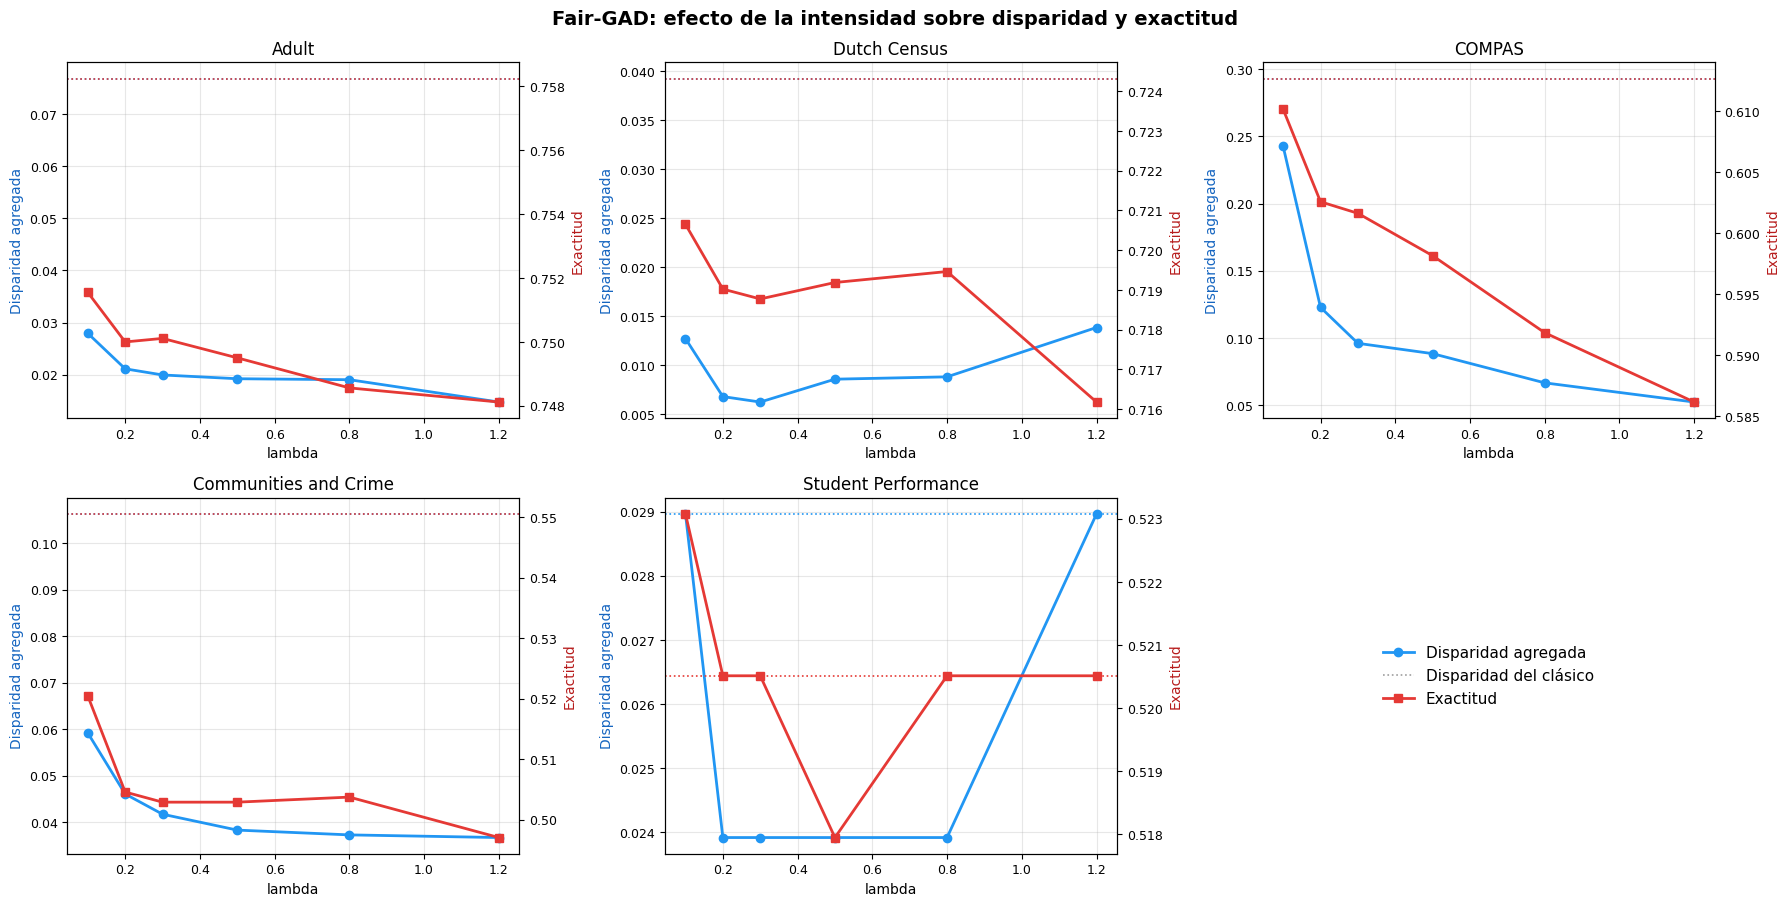

In [ ]:
# =========================================================
# FIGURA DEL BARRIDO DE FAIR-GAD (disposición 2 x 3)
# =========================================================
# Sustituye a la celda que genera barrido_gad.png. El único cambio es la
# disposición: Con dos filas y tres columnas cada panel conserva un tamaño
# utilizable. Solo replotea: no vuelve a ejecutar ningún barrido.

nombres = [cfg.DATASETS[d].display_name for d in DATASETS]
NCOLS = 3
NROWS = int(np.ceil(len(nombres) / NCOLS))

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(6.0 * NCOLS, 4.6 * NROWS))
axes = np.array(axes).flatten()

for ax, nombre in zip(axes, nombres):
    sub = barrido_gad[barrido_gad["Dataset"] == nombre].groupby("lambda").mean(numeric_only=True)
    ax.plot(sub.index, sub["D_g"], marker="o", color="#2196F3", linewidth=2,
            label="Disparidad")
    ax.axhline(sub["D_g"].iloc[0] - sub["Delta D_g"].iloc[0], color="#2196F3",
               linestyle=":", linewidth=1.2, label="Disparidad del clásico")
    ax2 = ax.twinx()
    ax2.plot(sub.index, sub["Accuracy"], marker="s", color="#E53935", linewidth=2,
             label="Exactitud")
    ax2.axhline(sub["Accuracy"].iloc[0] - sub["Delta Acc"].iloc[0], color="#E53935",
                linestyle=":", linewidth=1.2)
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("lambda", fontsize=10)
    ax.set_ylabel("Disparidad agregada", fontsize=10, color="#1565C0")
    ax2.set_ylabel("Exactitud", fontsize=10, color="#B71C1C")
    ax.tick_params(labelsize=9); ax2.tick_params(labelsize=9)
    ax.grid(alpha=0.3)

# Leyenda única en el hueco que deja el quinto panel, en lugar de dentro de uno
# de los ejes, donde tapaba las curvas.
sobrantes = axes[len(nombres):]
manejadores = [
    plt.Line2D([], [], color="#2196F3", marker="o", linewidth=2, label="Disparidad agregada"),
    plt.Line2D([], [], color="#9E9E9E", linestyle=":", linewidth=1.2,
               label="Disparidad del clásico"),
    plt.Line2D([], [], color="#E53935", marker="s", linewidth=2, label="Exactitud"),
]
for ax in sobrantes:
    ax.axis("off")
if len(sobrantes):
    sobrantes[0].legend(handles=manejadores, loc="center", fontsize=11, frameon=False)

plt.suptitle("Fair-GAD: efecto de la intensidad sobre disparidad y exactitud",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

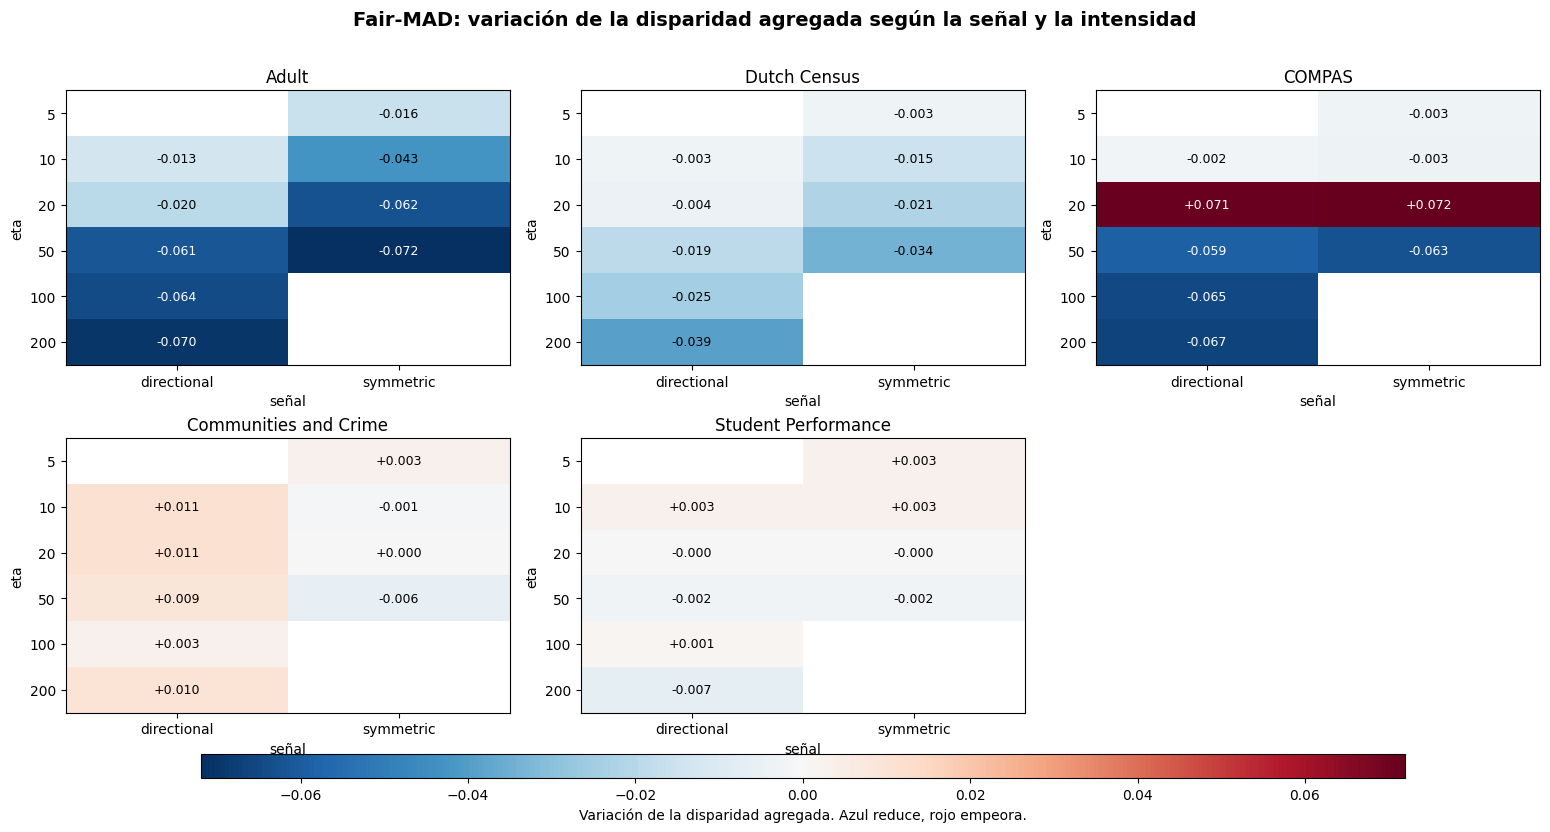

In [ ]:
# =========================================================
# FIGURA DEL BARRIDO DE FAIR-MAD (disposición 2 x 3)
# =========================================================
# Sustituye a la celda que genera barrido_mad.png. Mismo cambio de disposición
# que en la figura de Fair-GAD. Se añade además una escala de color común a los
# cinco conjuntos: con una escala independiente por panel, un +0,003 en Student
# se representaba con la misma intensidad de rojo que un +0,071 en COMPAS, lo
# que invita a comparar entre paneles cosas que no son comparables. La barra de
# color pasa a ser única para toda la figura.

nombres = [cfg.DATASETS[d].display_name for d in DATASETS]
NCOLS = 3
NROWS = int(np.ceil(len(nombres) / NCOLS))

pivotes = {}
for nombre in nombres:
    pivotes[nombre] = (barrido_mad[barrido_mad["Dataset"] == nombre]
                       .pivot_table(index="eta", columns="modo",
                                    values="Delta D_g", aggfunc="mean"))

lim = max(float(np.nanmax(np.abs(p.to_numpy()))) for p in pivotes.values()) or 1e-6

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(5.2 * NCOLS, 4.4 * NROWS))
axes = np.array(axes).flatten()

im = None
for ax, nombre in zip(axes, nombres):
    piv = pivotes[nombre]
    datos = piv.to_numpy()
    im = ax.imshow(datos, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, fontsize=10)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=10)
    ax.set_xlabel("señal", fontsize=10)
    ax.set_ylabel("eta", fontsize=10)
    ax.set_title(nombre, fontsize=12)
    for i in range(datos.shape[0]):
        for j in range(datos.shape[1]):
            v = datos[i, j]
            if np.isfinite(v):
                # Texto claro sobre celdas saturadas, oscuro sobre las suaves.
                color = "white" if abs(v) > 0.6 * lim else "black"
                ax.text(j, i, f"{v:+.3f}", ha="center", va="center",
                        fontsize=9, color=color)

for ax in axes[len(nombres):]:
    ax.axis("off")

plt.suptitle("Fair-MAD: variación de la disparidad agregada según la señal y la intensidad",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
cbar = fig.colorbar(im, ax=axes.tolist(), orientation="horizontal",
                    fraction=0.035, pad=0.06, aspect=50)
cbar.set_label("Variación de la disparidad agregada. Azul reduce, rojo empeora.", fontsize=10)
plt.show()

In [ ]:
# =========================================================
# CALIBRACIÓN DE OULAD CON EL ATRIBUTO SENSIBLE DE DISCAPACIDAD
# =========================================================
# OULAD no participó en la búsqueda original porque su disparidad de partida
# con el atributo de género es exactamente nula y ninguna configuración podía
# alterarla. Al pasar a la discapacidad, la disparidad de partida es 0,0920 y el
# conjunto entra en el procedimiento en las mismas condiciones que los otros
# cinco: mismas semillas de exploración, mismas rejillas y mismo criterio de
# selección, declarado antes de ejecutar el barrido.
#
# La celda es aditiva. Solo calcula las filas de OULAD y las concatena con los
# barridos ya guardados, de modo que los resultados de los cinco conjuntos
# restantes no se recalculan ni pueden alterarse.
#
# Coste: 6 intensidades de Fair-GAD y 9 configuraciones de Fair-MAD, por 3
# semillas, son 45 entrenamientos sobre un conjunto de 25.185 instancias. Se
# guarda un punto de control tras cada semilla, de modo que la ejecución puede
# interrumpirse y reanudarse sin perder lo hecho.

DATASET_CAL = "oulad"
MODO_SENSIBLE_POR_DATASET = {"oulad": "disability"}

def modo_sensible(dataset):
    """Modo sensible de un conjunto en la calibración. None usa el del cargador."""
    return MODO_SENSIBLE_POR_DATASET.get(dataset)

# --- Redefinición de datos_de con soporte de modo sensible ------------------
# Idéntica a la original salvo por el parámetro sensitive_mode. Se redefine con
# el mismo nombre para que evaluar_gad y evaluar_mad la usen sin cambios. Las
# entradas ya cacheadas de los cinco conjuntos siguen siendo válidas, porque en
# ellos el modo es el del cargador.
def datos_de(dataset, semilla):
    """Partición y métricas del modelo clásico, con caché."""
    clave = (dataset, semilla)
    if clave in _CACHE:
        return _CACHE[clave]
    Xtr, Xte, ytr, yte, str_, ste, fnames, dcfg = runner.load_and_split(
        dataset, sensitive_mode=modo_sensible(dataset),
        test_size=TEST_SIZE, random_state=semilla,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)
    tarea = "binary" if int(len(np.unique(ytr))) == 2 else "multiclass"
    base = LamdaClassifier(alpha=ALPHA, operator=OPERATOR).fit(Xtr, ytr)
    m_base = reporting.summarize_model_metrics(
        yte, base.predict(Xte), ste, task=tarea,
        thresholds=THRESHOLDS, weights=pesos_de(dataset),
        class_aggregation=CLASS_AGGREGATION)
    from sklearn.metrics import f1_score
    valores, cuentas = np.unique(yte, return_counts=True)
    mayoritaria = valores[int(np.argmax(cuentas))]
    y_trivial = np.full_like(yte, mayoritaria)
    acc_trivial = float(cuentas.max() / len(yte))
    f1_trivial = float(f1_score(yte, y_trivial, average="macro", zero_division=0))
    _CACHE[clave] = dict(Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, str_=str_, ste=ste,
                         tarea=tarea, base=m_base, acc_trivial=acc_trivial,
                         f1_trivial=f1_trivial)
    return _CACHE[clave]

# --- Esquema por bloques de OULAD -------------------------------------------
# Depende del tamaño y del número de clases, no del atributo sensible, de modo
# que coincide con el que emplea el conjunto en el notebook de mitigación.
_d0 = datos_de(DATASET_CAL, SEMILLAS_EXPLORACION[0])
_bs = cfg.tamano_bloque(len(_d0["Xtr"]), BLOQUES_OBJETIVO, TAMANO_BLOQUE_MINIMO)
_mg, _mp = cfg.soportes_minimos(len(_d0["Xtr"]),
                                n_classes=int(len(np.unique(_d0["ytr"]))),
                                block_size=_bs, modo=MODO_SOPORTES)
CONFIG_BLOQUES[DATASET_CAL] = dict(block_size=_bs, min_group_size=_mg,
                                   min_positive_size=_mp)
print(f"[{DATASET_CAL}/{modo_sensible(DATASET_CAL)}] bloque={_bs} | "
      f"soportes {_mg}/{_mp} | D_g del clásico = "
      f"{_d0['base']['mean_disparity']:.4f} (semilla {SEMILLAS_EXPLORACION[0]})")

# --- Barrido -----------------------------------------------------------------
_ruta_gad_o = os.path.join(RESULTADOS_DIR, "barrido_gad_oulad.csv")
_ruta_mad_o = os.path.join(RESULTADOS_DIR, "barrido_mad_oulad.csv")

filas_gad_o, filas_mad_o = [], []
for semilla in SEMILLAS_EXPLORACION:
    ti = time.time()
    for lam in LAMBDAS:
        filas_gad_o.append(evaluar_gad(DATASET_CAL, semilla, lam))
    print(f"[semilla {semilla}] Fair-GAD: {len(LAMBDAS)} configuraciones en "
          f"{time.time()-ti:.0f}s", flush=True)

    ti = time.time()
    for modo, eta in MAD_GRID:
        filas_mad_o.append(evaluar_mad(DATASET_CAL, semilla, modo, eta))
    print(f"[semilla {semilla}] Fair-MAD: {len(MAD_GRID)} configuraciones en "
          f"{time.time()-ti:.0f}s", flush=True)

    # Punto de control tras cada semilla.
    pd.DataFrame(filas_gad_o).to_csv(_ruta_gad_o, index=False)
    pd.DataFrame(filas_mad_o).to_csv(_ruta_mad_o, index=False)

barrido_gad_oulad = pd.DataFrame(filas_gad_o)
barrido_mad_oulad = pd.DataFrame(filas_mad_o)

# --- Concatenación con los barridos existentes ------------------------------
# Se deja constancia del atributo sensible empleado en cada fila, para que el
# fichero sea autoexplicativo y no dependa de recordar esta decisión.
def _con_modo(df, modo):
    df = df.copy()
    df["modo_sensible"] = modo
    return df

barrido_gad = pd.concat([_con_modo(barrido_gad[barrido_gad["dataset"] != DATASET_CAL],
                                   "por defecto del cargador"),
                         _con_modo(barrido_gad_oulad, modo_sensible(DATASET_CAL))],
                        ignore_index=True)
barrido_mad = pd.concat([_con_modo(barrido_mad[barrido_mad["dataset"] != DATASET_CAL],
                                   "por defecto del cargador"),
                         _con_modo(barrido_mad_oulad, modo_sensible(DATASET_CAL))],
                        ignore_index=True)

barrido_gad.to_csv(os.path.join(RESULTADOS_DIR, "barrido_gad.csv"), index=False)
barrido_mad.to_csv(os.path.join(RESULTADOS_DIR, "barrido_mad.csv"), index=False)
print(f"\nBarridos ampliados: {len(barrido_gad)} filas en Fair-GAD y "
      f"{len(barrido_mad)} en Fair-MAD, sobre "
      f"{barrido_gad['dataset'].nunique()} conjuntos.")

display(barrido_gad_oulad.groupby("lambda")
        [["Delta D_g", "Delta Acc", "D_g", "Accuracy", "F1_macro"]].mean().round(4))
display(barrido_mad_oulad.groupby(["modo", "eta"])
        [["Delta D_g", "Delta Acc", "w_min", "atenuados"]].mean().round(4))

# --- Diagnóstico y selección con los seis conjuntos -------------------------
diag_gad = diagnosticar(barrido_gad, ["lambda"])
diag_mad = diagnosticar(barrido_mad, ["modo", "eta"])
diag_gad.to_csv(os.path.join(RESULTADOS_DIR, "diagnostico_gad.csv"), index=False)
diag_mad.to_csv(os.path.join(RESULTADOS_DIR, "diagnostico_mad.csv"), index=False)

print("\nDIAGNÓSTICO DE FAIR-GAD EN OULAD")
display(diag_gad[diag_gad["dataset"] == DATASET_CAL].drop(columns=["dataset"]).round(4))
print("DIAGNÓSTICO DE FAIR-MAD EN OULAD")
display(diag_mad[diag_mad["dataset"] == DATASET_CAL].drop(columns=["dataset"]).round(4))

sel_gad = seleccionar(diag_gad, "lambda", "Fair-GAD")
sel_mad = seleccionar(diag_mad, "eta", "Fair-MAD")

print("\nCONFIGURACIÓN ELEGIDA PARA FAIR-GAD")
display(sel_gad.drop(columns=["dataset", "modo", "Propuesta"]).round(4))
print("CONFIGURACIÓN ELEGIDA PARA FAIR-MAD")
display(sel_mad.drop(columns=["dataset", "Propuesta"]).round(4))

lam_dict  = {r["dataset"]: float(r["elegida"]) for _, r in sel_gad.iterrows()}
eta_dict  = {r["dataset"]: int(r["elegida"]) for _, r in sel_mad.iterrows()}
modo_dict = {r["dataset"]: (r["modo"] if r["modo"] != "—" else MODO_MAD_REFERENCIA)
             for _, r in sel_mad.iterrows()}

def _fmt(d, comilla=False):
    cuerpo = ",\n".join(f'    "{k}": ' + (f'"{v}"' if comilla else f"{v}")
                        for k, v in d.items())
    return "{\n" + cuerpo + ",\n}"

print("\n" + "=" * 70)
print("CONFIG. ELEGIDA (con OULAD)")
print("=" * 70)
print("LAMBDA_POR_DATASET =", _fmt(lam_dict))
print("ETA_POR_DATASET =", _fmt(eta_dict))
print("MODO_MAD_POR_DATASET =", _fmt(modo_dict, comilla=True))

incumplen = pd.concat([sel_gad, sel_mad])
incumplen = incumplen[incumplen["Origen"].str.startswith("respaldo")]
if len(incumplen):
    print("\nConfiguraciones sin ninguna alternativa factible (respaldo):")
    display(incumplen[["Propuesta", "elegida", "Delta D_g", "Delta Acc"]].round(4))

[oulad/disability] bloque=1260 | soportes 50/12 | D_g del clásico = 0.0526 (semilla 7)
[semilla 7] Fair-GAD: 6 configuraciones en 4s
[semilla 7] Fair-MAD: 9 configuraciones en 145s
[semilla 13] Fair-GAD: 6 configuraciones en 4s
[semilla 13] Fair-MAD: 9 configuraciones en 146s
[semilla 21] Fair-GAD: 6 configuraciones en 4s
[semilla 21] Fair-MAD: 9 configuraciones en 146s

Barridos ampliados: 108 filas en Fair-GAD y 162 en Fair-MAD, sobre 6 conjuntos.


,Delta D_g,Delta Acc,D_g,Accuracy,F1_macro
lambda,,,,,
0.1000,-0.0361,0.0300,0.0107,0.3187,0.2926
0.2000,-0.0380,0.0320,0.0088,0.3207,0.2935
0.3000,-0.0357,0.0350,0.0111,0.3238,0.2936
0.5000,-0.0346,0.0359,0.0121,0.3246,0.2942
0.8000,-0.0310,0.0440,0.0158,0.3327,0.2955
1.2000,-0.0319,0.0403,0.0148,0.3290,0.2940


Delta D_g  Delta Acc  w_min  atenuados
modo        eta                                        
directional 10      0.0105     0.0016 0.9204    14.6667
            20     -0.0003     0.0092 0.8527    15.3333
            50      0.0099     0.0188 0.6993    17.0000
            100     0.0172     0.0188 0.5387    17.0000
            200     0.0334     0.0109 0.3696    17.3333
symmetric   5      -0.0048    -0.0011 0.9562     8.3333
            10      0.0023     0.0008 0.9163    10.0000
            20     -0.0048     0.0051 0.8461    10.3333
            50     -0.0069     0.0125 0.6896    10.6667


DIAGNÓSTICO DE FAIR-GAD EN OULAD


,Dataset,lambda,Delta D_g,Delta Acc,Delta DI_min,F1 macro,F1 macro trivial,0 supera trivial,1 reduce,2 rendimiento,3 impacto dispar,4 estable,Puntuación,VÁLIDA
24,OULAD,0.1000,-0.0361,0.0300,0.1481,0.2926,0.1366,True,True,True,True,True,0.0361,True
25,OULAD,0.2000,-0.0380,0.0320,0.1638,0.2935,0.1366,True,True,True,True,True,0.0380,True
26,OULAD,0.3000,-0.0357,0.0350,0.1800,0.2936,0.1366,True,True,True,True,True,0.0357,True
27,OULAD,0.5000,-0.0346,0.0359,0.1904,0.2942,0.1366,True,True,True,True,True,0.0346,True
28,OULAD,0.8000,-0.0310,0.0440,0.3044,0.2955,0.1366,True,True,True,True,True,0.0310,True
29,OULAD,1.2000,-0.0319,0.0403,0.2697,0.2940,0.1366,True,True,True,True,True,0.0319,True


...

,elegida,Delta D_g,Delta Acc,Delta DI_min,Puntuación,Origen,Nº factibles
Dataset,,,,,,,
Adult,0.2000,-0.0557,-0.0082,0.1699,0.0475,criterio,6
Communities and Crime,0.1000,-0.0471,-0.0301,0.0932,0.0170,respaldo: ninguna configuración factible,0
COMPAS,0.3000,-0.1968,-0.0110,0.1820,0.1858,criterio,4
Dutch Census,0.2000,-0.0325,-0.0053,0.0679,0.0272,criterio,6
OULAD,0.1000,-0.0361,0.0300,0.1481,0.0361,criterio,6
Student Performance,0.2000,-0.0051,0.0000,0.0288,0.0051,criterio,4


CONFIGURACIÓN ELEGIDA PARA FAIR-MAD


,elegida,modo,Delta D_g,Delta Acc,Delta DI_min,Puntuación,Origen,Nº factibles
Dataset,,,,,,,,
Adult,5,symmetric,-0.0160,-0.0066,0.0435,0.0093,criterio,3
Communities and Crime,5,symmetric,0.0029,0.0025,-0.0061,-0.0029,respaldo: ninguna configuración factible,0
COMPAS,5,symmetric,-0.0031,-0.0013,-0.0003,0.0019,respaldo: ninguna configuración factible,0
Dutch Census,10,symmetric,-0.0154,-0.0098,0.0236,0.0056,criterio,4
OULAD,5,symmetric,-0.0048,-0.0011,0.0044,0.0037,respaldo: ninguna configuración factible,0
Student Performance,5,symmetric,0.0033,0.0051,-0.0149,-0.0033,respaldo: ninguna configuración factible,0



PEGAR EN EL PANEL DEL NOTEBOOK 5.2
LAMBDA_POR_DATASET = {
    "adult": 0.2,
    "communities": 0.1,
    "compas": 0.3,
    "dutch": 0.2,
    "oulad": 0.1,
    "student": 0.2,
}
ETA_POR_DATASET = {
    "adult": 5,
    "communities": 5,
    "compas": 5,
    "dutch": 10,
    "oulad": 5,
    "student": 5,
}
MODO_MAD_POR_DATASET = {
    "adult": "symmetric",
    "communities": "symmetric",
    "compas": "symmetric",
    "dutch": "symmetric",
    "oulad": "symmetric",
    "student": "symmetric",
}

Configuraciones sin ninguna alternativa factible (respaldo):


,Propuesta,elegida,Delta D_g,Delta Acc
Dataset,,,,
Communities and Crime,Fair-GAD,0.1000,-0.0471,-0.0301
Communities and Crime,Fair-MAD,5.0000,0.0029,0.0025
COMPAS,Fair-MAD,5.0000,-0.0031,-0.0013
OULAD,Fair-MAD,5.0000,-0.0048,-0.0011
Student Performance,Fair-MAD,5.0000,0.0033,0.0051


In [ ]:
# Reemplazo completo de la celda de selección de este notebook. Aplicar DESPUÉS
# de que la calibración de OULAD haya terminado. Retira la inyección de valores
# modales para OULAD, que dejó de tener sentido cuando el conjunto pasó a
# participar en la búsqueda con el atributo de discapacidad.

sel_gad = seleccionar(diag_gad, "lambda", "Fair-GAD")
sel_mad = seleccionar(diag_mad, "eta", "Fair-MAD")

print("CONFIGURACIÓN ELEGIDA PARA FAIR-GAD")
display(sel_gad.drop(columns=["dataset", "modo", "Propuesta"]).round(4))
print("\nCONFIGURACIÓN ELEGIDA PARA FAIR-MAD")
display(sel_mad.drop(columns=["dataset", "Propuesta"]).round(4))

# Diccionarios listos para pegar en el panel de mitigación. El respaldo se
# traslada tal cual. Los seis conjuntos proceden ya del barrido: OULAD se
# incorporó con el atributo sensible de discapacidad, con el que su disparidad
# de partida deja de ser nula y la búsqueda resulta informativa.
lam_dict  = {r["dataset"]: float(r["elegida"]) for _, r in sel_gad.iterrows()}
eta_dict  = {r["dataset"]: int(r["elegida"]) for _, r in sel_mad.iterrows()}
modo_dict = {r["dataset"]: (r["modo"] if r["modo"] != "—" else MODO_MAD_REFERENCIA)
             for _, r in sel_mad.iterrows()}

def _fmt(d, comilla=False):
    cuerpo = ",\n".join(f'    "{k}": ' + (f'"{v}"' if comilla else f"{v}")
                         for k, v in d.items())
    return "{\n" + cuerpo + ",\n}"

print("\n" + "=" * 70)
print("CONFIG. ELEGIDA (con OULAD)")
print("=" * 70)
print("LAMBDA_POR_DATASET =", _fmt(lam_dict))
print("ETA_POR_DATASET =", _fmt(eta_dict))
print("MODO_MAD_POR_DATASET =", _fmt(modo_dict, comilla=True))

incumplen = pd.concat([sel_gad, sel_mad])
incumplen = incumplen[incumplen["Origen"].str.startswith("respaldo")]
if len(incumplen):
    display(incumplen[["Propuesta", "elegida", "Delta D_g", "Delta Acc"]].round(4))

CONFIGURACIÓN ELEGIDA PARA FAIR-GAD


,elegida,Delta D_g,Delta Acc,Delta DI_min,Puntuación,Origen,Nº factibles
Dataset,,,,,,,
Adult,0.2000,-0.0557,-0.0082,0.1699,0.0475,criterio,6
Communities and Crime,0.1000,-0.0471,-0.0301,0.0932,0.0170,respaldo: ninguna configuración factible,0
COMPAS,0.3000,-0.1968,-0.0110,0.1820,0.1858,criterio,4
Dutch Census,0.2000,-0.0325,-0.0053,0.0679,0.0272,criterio,6
OULAD,0.1000,-0.0361,0.0300,0.1481,0.0361,criterio,6
Student Performance,0.2000,-0.0051,0.0000,0.0288,0.0051,criterio,4



CONFIGURACIÓN ELEGIDA PARA FAIR-MAD


,elegida,modo,Delta D_g,Delta Acc,Delta DI_min,Puntuación,Origen,Nº factibles
Dataset,,,,,,,,
Adult,5,symmetric,-0.0160,-0.0066,0.0435,0.0093,criterio,3
Communities and Crime,5,symmetric,0.0029,0.0025,-0.0061,-0.0029,respaldo: ninguna configuración factible,0
COMPAS,5,symmetric,-0.0031,-0.0013,-0.0003,0.0019,respaldo: ninguna configuración factible,0
Dutch Census,10,symmetric,-0.0154,-0.0098,0.0236,0.0056,criterio,4
OULAD,5,symmetric,-0.0048,-0.0011,0.0044,0.0037,respaldo: ninguna configuración factible,0
Student Performance,5,symmetric,0.0033,0.0051,-0.0149,-0.0033,respaldo: ninguna configuración factible,0



PEGAR EN EL PANEL DEL NOTEBOOK 5.2
LAMBDA_POR_DATASET = {
    "adult": 0.2,
    "communities": 0.1,
    "compas": 0.3,
    "dutch": 0.2,
    "oulad": 0.1,
    "student": 0.2,
}
ETA_POR_DATASET = {
    "adult": 5,
    "communities": 5,
    "compas": 5,
    "dutch": 10,
    "oulad": 5,
    "student": 5,
}
MODO_MAD_POR_DATASET = {
    "adult": "symmetric",
    "communities": "symmetric",
    "compas": "symmetric",
    "dutch": "symmetric",
    "oulad": "symmetric",
    "student": "symmetric",
}


,Propuesta,elegida,Delta D_g,Delta Acc
Dataset,,,,
Communities and Crime,Fair-GAD,0.1000,-0.0471,-0.0301
Communities and Crime,Fair-MAD,5.0000,0.0029,0.0025
COMPAS,Fair-MAD,5.0000,-0.0031,-0.0013
OULAD,Fair-MAD,5.0000,-0.0048,-0.0011
Student Performance,Fair-MAD,5.0000,0.0033,0.0051


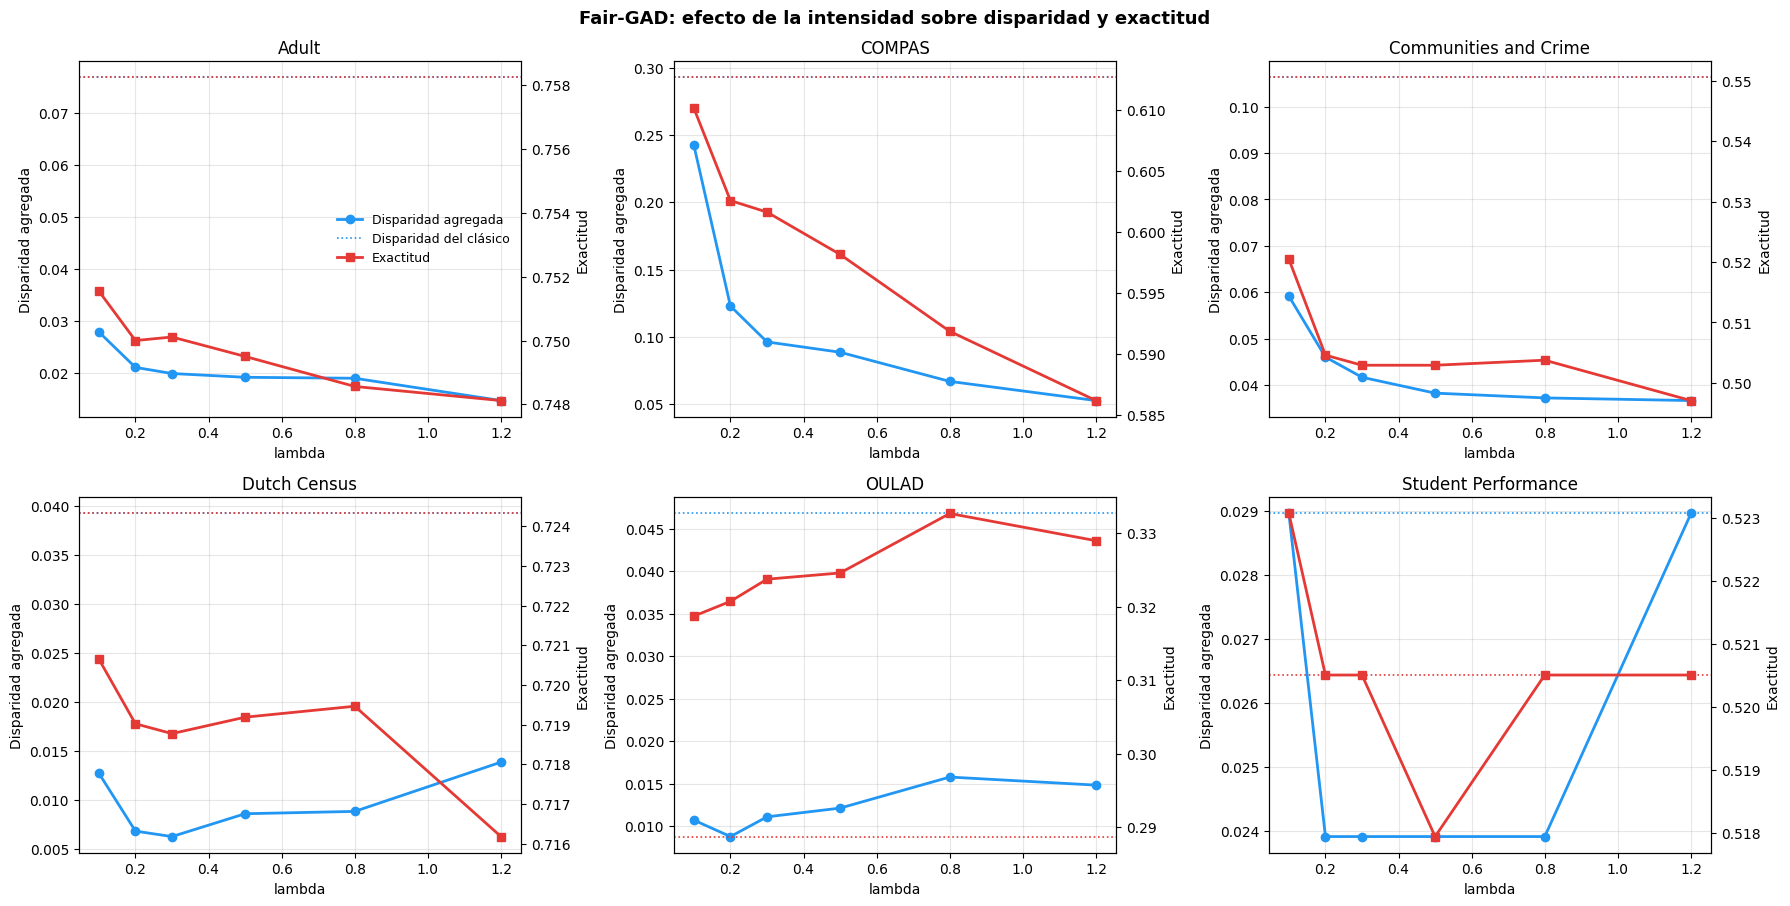

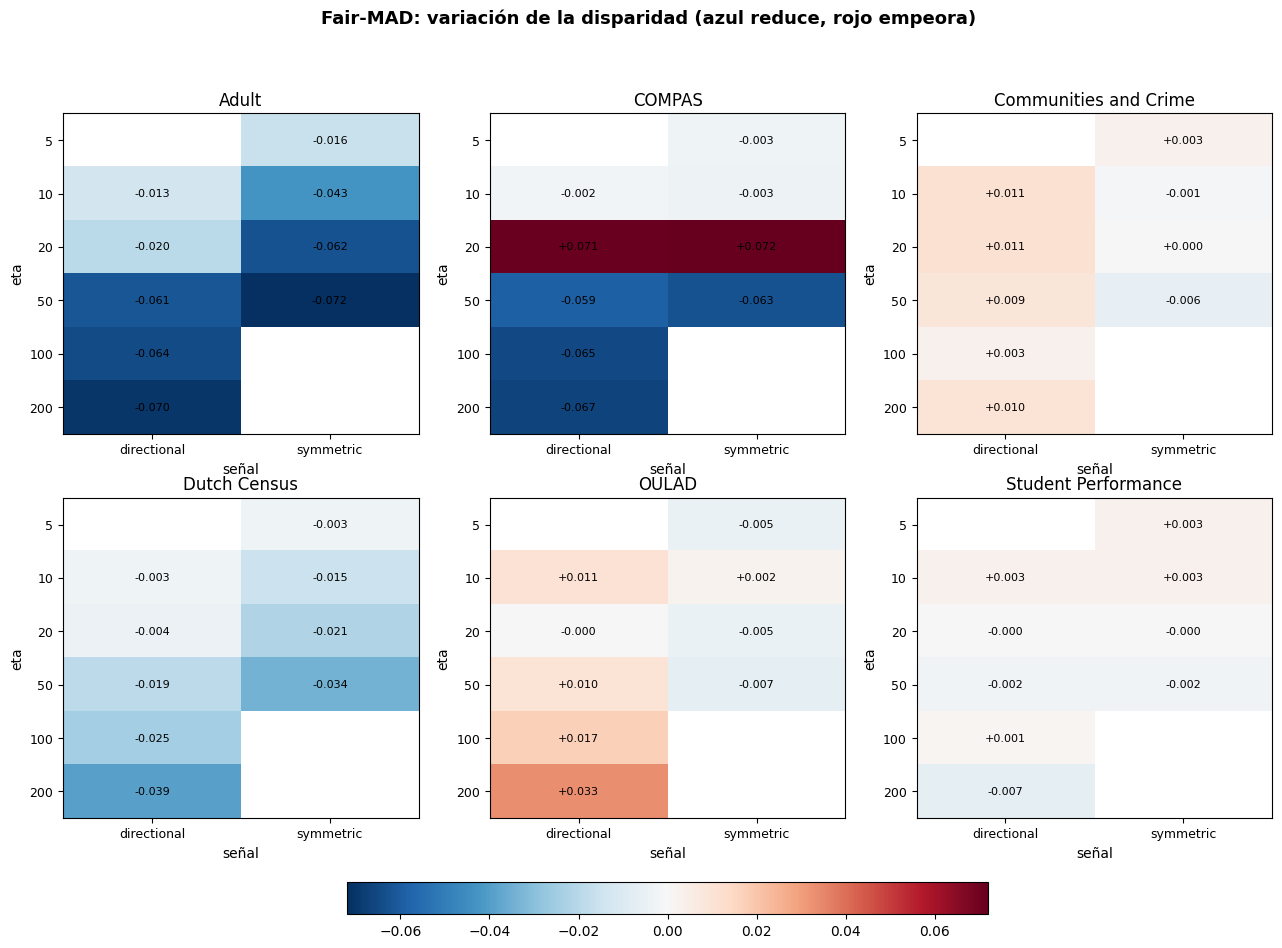

In [ ]:
# Corrección de las dos celdas de figura del notebook de exploración. Recorren
# la lista DATASETS, que sigue teniendo cinco conjuntos, de modo que dibujarían
# cinco paneles sobre un barrido que ya tiene seis. Se toma la lista de los
# propios barridos, que es la fuente correcta. Solo replotea: no reejecuta nada.

nombres = sorted(barrido_gad["Dataset"].unique().tolist())
NCOLS = 3
NROWS = int(np.ceil(len(nombres) / NCOLS))

# ---------- Fair-GAD ----------
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(6.0 * NCOLS, 4.6 * NROWS))
axes = np.array(axes).flatten()
for ax, nombre in zip(axes, nombres):
    sub = (barrido_gad[barrido_gad["Dataset"] == nombre]
           .groupby("lambda").mean(numeric_only=True))
    ax.plot(sub.index, sub["D_g"], marker="o", color="#2196F3", linewidth=2,
            label="Disparidad agregada")
    ax.axhline(sub["D_g"].iloc[0] - sub["Delta D_g"].iloc[0], color="#2196F3",
               linestyle=":", linewidth=1.2, label="Disparidad del clásico")
    ax2 = ax.twinx()
    ax2.plot(sub.index, sub["Accuracy"], marker="s", color="#E53935", linewidth=2)
    ax2.axhline(sub["Accuracy"].iloc[0] - sub["Delta Acc"].iloc[0], color="#E53935",
                linestyle=":", linewidth=1.2)
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("lambda", fontsize=10)
    ax.set_ylabel("Disparidad agregada", fontsize=10)
    ax2.set_ylabel("Exactitud", fontsize=10)
    ax.grid(alpha=0.3)
for ax in axes[len(nombres):]:
    ax.axis("off")
handles = [
    plt.Line2D([], [], color="#2196F3", marker="o", linewidth=2,
               label="Disparidad agregada"),
    plt.Line2D([], [], color="#2196F3", linestyle=":", linewidth=1.2,
               label="Disparidad del clásico"),
    plt.Line2D([], [], color="#E53935", marker="s", linewidth=2,
               label="Exactitud"),
]
axes[0].legend(handles=handles, fontsize=9, loc="best", frameon=False)
plt.suptitle("Fair-GAD: efecto de la intensidad sobre disparidad y exactitud",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------- Fair-MAD ----------
pivotes = {n: (barrido_mad[barrido_mad["Dataset"] == n]
               .pivot_table(index="eta", columns="modo", values="Delta D_g",
                            aggfunc="mean")) for n in nombres}
lim = max(float(np.nanmax(np.abs(p.to_numpy()))) for p in pivotes.values()) or 1e-6

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(5.2 * NCOLS, 5.2 * NROWS))
axes = np.array(axes).flatten()
im = None
for ax, nombre in zip(axes, nombres):
    piv = pivotes[nombre]
    datos = piv.to_numpy()
    im = ax.imshow(datos, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, fontsize=9)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index, fontsize=9)
    ax.set_xlabel("señal"); ax.set_ylabel("eta"); ax.set_title(nombre, fontsize=12)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = datos[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8)
for ax in axes[len(nombres):]:
    ax.axis("off")
fig.colorbar(im, ax=axes.tolist(), orientation="horizontal",
             fraction=0.04, pad=0.08)
plt.suptitle("Fair-MAD: variación de la disparidad (azul reduce, rojo empeora)",
             fontsize=13, fontweight="bold")
plt.show()